# Notebook 9: Introduction to PyG 
We'll see how to approach the problem of [Zachary's karate club](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) with the utilities from PyG.

A difference from the original version, though, is that the dataset was adapted for multi-class classification so we have 4 possible labels instead of two.

In [28]:
import torch
!pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable


In [29]:
# For visualization
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import clear_output

Let's define some functions that we will use to **visualize the data, and the embedding**.
We'll use the utilities from `networkx` for visualizing graphs

In [30]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()

In [43]:
def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(5,5))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()

Now, let's look into the KarateClub dataset's properties

In [32]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()

In [33]:
# General properties
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [34]:
# Properties of the graph
data = dataset[0] 

print(data)
print('==============================================================')
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [35]:
# Edge properties
edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

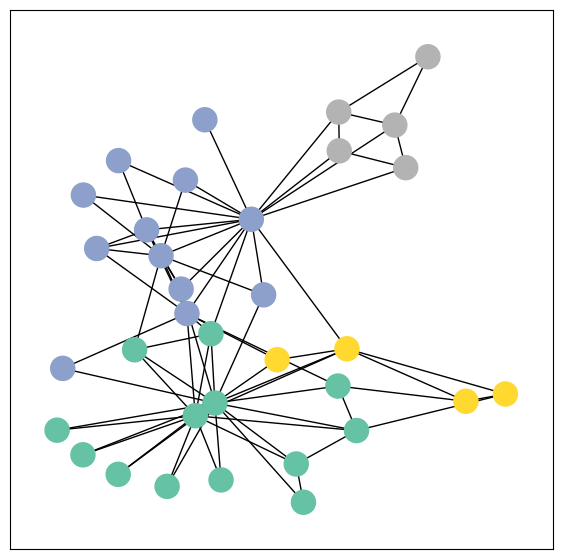

In [36]:
# Visualize graph with our function
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

Now, we **define a GCN network** to learn the graph properties and predict the classes!

In [37]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        torch.manual_seed(12345) # ensure reproducible results
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.
        
        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Embedding shape: [34, 2]


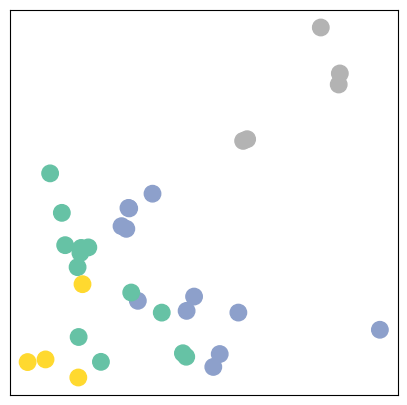

In [44]:
# Before we train, let's see the embedding 
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize_embedding(h, color=data.y)

Finally, we **train** the network to predict the label of each node

In [62]:
# Define loss and optimizer
criterion = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [63]:
# Train loop
def train(data):
    optimizer.zero_grad()  # Clear gradients
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes
    loss.backward()  # Derive gradients
    optimizer.step()  # Update parameters based on gradients
    return loss, h

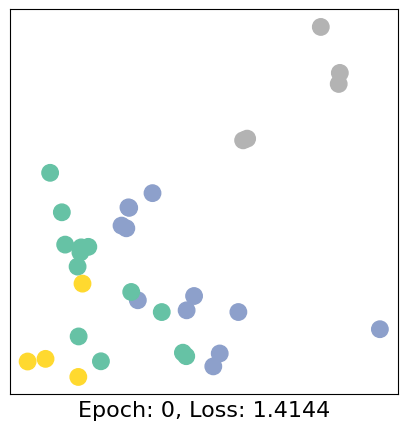

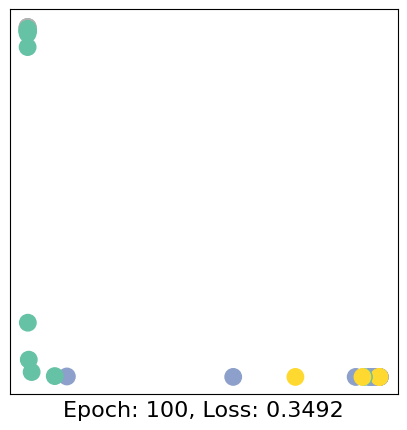

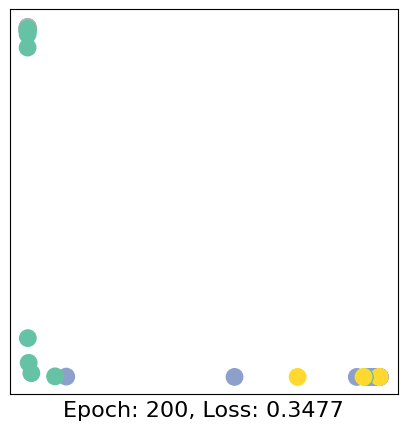

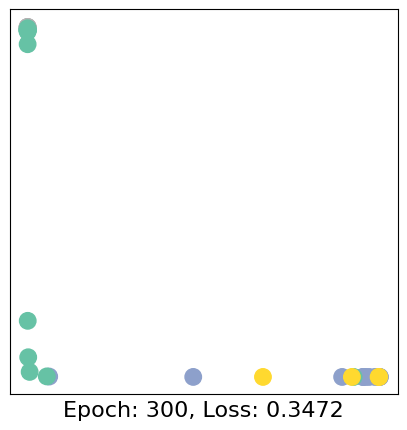

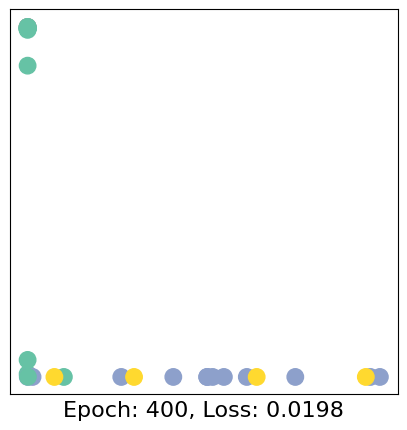

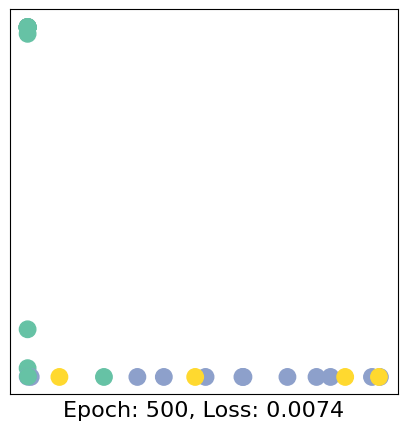

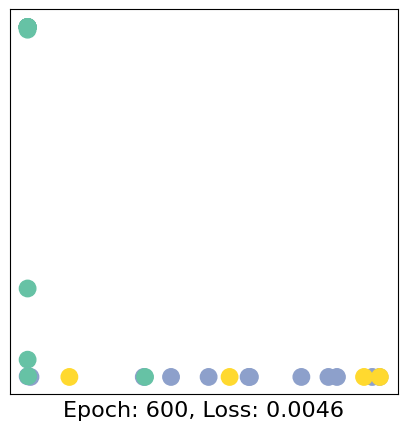

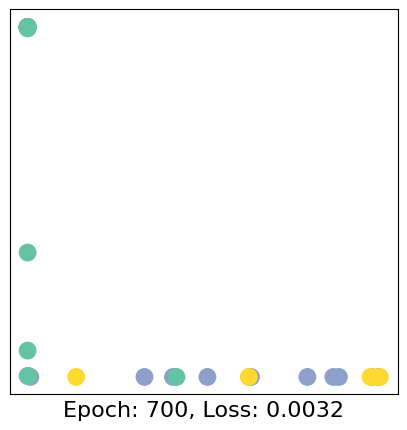

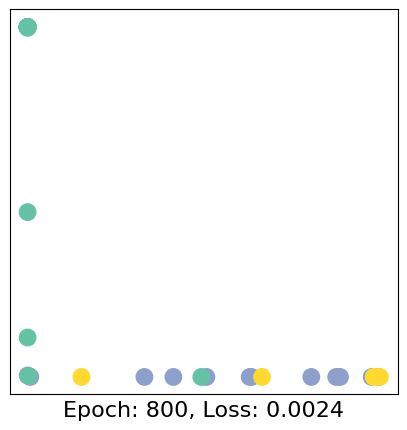

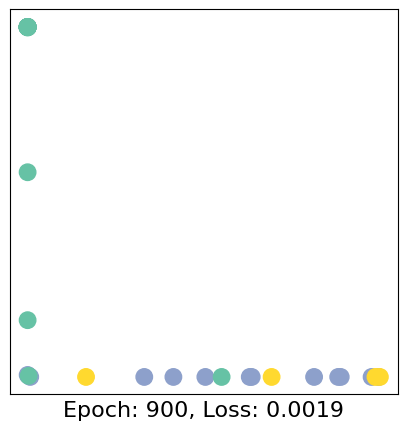

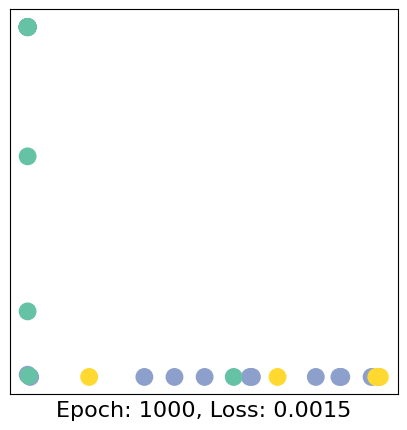

In [64]:
import time 

for epoch in range(1001):
    loss, h = train(data)
    if epoch % 100 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)

Is this actually good enough? Why? Or why not?

tensor([1, 2, 1, 2, 3, 3, 3, 2, 0, 0, 3, 2, 2, 1, 3, 3, 3, 1, 3, 0, 3, 1, 3, 0,
        2, 2, 3, 1, 0, 3, 3, 1, 3, 3])


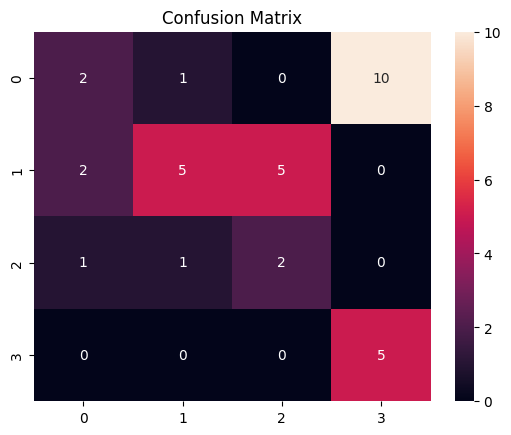

In [66]:
!pip install -q seaborn
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred, emb = model(data.x, data.edge_index)
pred_classes = pred.argmax(dim=1)  # shape [num_nodes]
print(pred_classes)
cm = confusion_matrix(data.y.cpu(),pred_classes.cpu())

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [70]:
train_correct = (pred_classes[data.train_mask] == data.y[data.train_mask]).sum().item()
train_acc = train_correct / data.train_mask.sum().item()
print(f'Training Accuracy: {train_acc:.4f}')

all_correct = (pred_classes == data.y).sum().item()
all_acc = all_correct / data.y.sum().item()
print(f'Total Accuracy: {all_acc:.4f}')

Training Accuracy: 1.0000
Total Accuracy: 0.4000
